In [62]:
from transformer_architecture_moe import MoE_Transformer
from transformer_architecture_base import Transformer

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(DEVICE)

2.5.1
cuda


In [63]:
df = pd.read_csv("data/cleaned_dataset.csv")
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,179.426579,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,179.426579,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,211.382074,60.0,652230.0,33.93911,67.709953


In [64]:
df[df["Entity"] == "Somalia"]

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
2520,Somalia,2000,1.892501,0.4,93.28,0.23,0.0,0.00,0.000000,340.10217,11.22,490.000000,350.168162,25.0,637657.0,5.152149,46.199616
2521,Somalia,2001,4.504616,0.4,93.26,0.25,0.0,0.00,0.000000,332.43317,11.32,510.000000,350.168162,25.0,637657.0,5.152149,46.199616
2522,Somalia,2002,7.400000,0.5,92.58,0.26,0.0,0.00,0.000000,346.37854,11.39,569.999993,350.168162,25.0,637657.0,5.152149,46.199616
2523,Somalia,2003,9.708441,0.5,92.80,0.26,0.0,0.00,0.000000,334.05520,11.51,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2524,Somalia,2004,12.304850,0.6,93.00,0.26,0.0,0.00,0.000000,322.42703,11.48,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2525,Somalia,2005,14.900722,0.6,93.30,0.27,0.0,0.00,0.000000,314.66333,11.47,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2526,Somalia,2006,15.233786,0.7,93.47,0.28,0.0,0.00,0.000000,307.72528,11.60,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2527,Somalia,2007,20.100733,0.7,93.02,0.29,0.0,0.00,0.000000,302.79350,11.53,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2528,Somalia,2008,22.710230,0.8,93.37,0.30,0.0,0.00,0.000000,291.03380,11.74,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2529,Somalia,2009,25.329666,1.0,93.63,0.31,0.0,0.00,0.000000,283.20413,11.82,610.000014,350.168162,25.0,637657.0,5.152149,46.199616


# Data Processing

In [65]:
SEQ_LEN = 8
VAL_TIME = 1
TEST_TIME = 1
OOD_TEST_TIME = 2

### Train Val Test Splitting

In [66]:
entity = df["Entity"].unique()
year = df["Year"].unique()
year_start = np.arange(year.min(), year.max() - SEQ_LEN + 1, 1)
print(year_start)
len(entity), len(year), len(year_start)

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012]


(145, 21, 13)

In [67]:
train_year = year_start[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME]
val_year = year_start[- VAL_TIME - TEST_TIME - OOD_TEST_TIME: - TEST_TIME - OOD_TEST_TIME]
test_year = year_start[- TEST_TIME - OOD_TEST_TIME: - OOD_TEST_TIME]
ood_test_year = year_start[- OOD_TEST_TIME:]
train_year, val_year, test_year, ood_test_year

(array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008]),
 array([2009]),
 array([2010]),
 array([2011, 2012]))

### Normalization

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [69]:
scaler_years = set(year[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME])
scaler_years

{np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016)}

In [70]:
scaler_df = df[df["Year"].isin(scaler_years)].drop(columns=["Entity", "Year"])

In [71]:
scaler.fit(scaler_df)

,copy,True
,with_mean,True
,with_std,True


In [72]:
df[df.columns[2:]] = scaler.transform(df[df.columns[2:]])

df_global = df.drop(columns=["Entity"]).groupby('Year', as_index=False).mean()
df_global.head()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,2000,-0.173365,-0.102433,0.055485,-0.053051,-0.000135,-0.077248,0.011062,-0.038259,0.242942,-0.041096,-0.275143,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
1,2001,-0.155280,-0.088909,0.039796,-0.050245,0.005179,-0.082559,-0.013827,-0.035893,0.212047,-0.038231,-0.280080,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
2,2002,-0.128914,-0.075306,0.036260,-0.043046,0.005462,-0.076877,-0.003851,-0.024942,0.173836,-0.036085,-0.258630,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
3,2003,-0.108627,-0.061324,0.023585,-0.034198,0.001520,-0.074998,-0.019013,-0.011661,0.178610,-0.027841,-0.190461,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
4,2004,-0.088583,-0.048111,0.018931,-0.026900,0.011044,-0.060752,-0.014136,0.006960,0.150179,-0.019054,-0.121281,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18


### Entity - Year pair

In [73]:
def generate_pair(years):
    pairs = []

    for year in years:
        for e in entity:
            pairs.append((e, year))

    return pairs

In [74]:
ds_train = generate_pair(train_year)
ds_val = generate_pair(val_year)
ds_test = generate_pair(test_year)
ds_ood_test = generate_pair(ood_test_year)

len(ds_train), len(ds_val), len(ds_test), len(ds_ood_test)

(1305, 145, 145, 290)

### Data Loader

In [75]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

In [ ]:
BATCH_SIZE = 128                                                                                  
EPOCHS = 500
LEARNING_RATE = 2.5e-4

HIDDEN_DIM = 384

In [77]:
train_loader = DataLoader(ds_train, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ds_val, batch_size = BATCH_SIZE)
test_loader = DataLoader(ds_test, batch_size = BATCH_SIZE)
ood_test_loader = DataLoader(ds_ood_test, batch_size = BATCH_SIZE)

In [78]:
col_count = len(df_global.columns)

model = MoE_Transformer(
    hidden_dim=HIDDEN_DIM,
    seq_len=SEQ_LEN,
    corpus_size=col_count,
    encoder_attention_heads=6,
    encoder_blocks=8,
    encoder_n_expert=4,
    decoder_attention_heads=6,
    decoder_blocks=8,
    decoder_n_expert=4,
    dropout=0.15,
    use_embedding=False,
    embedding_replacement=torch.nn.Linear(col_count, HIDDEN_DIM)
).to(DEVICE)

criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(EPOCHS*len(train_loader)*0.1),
    num_training_steps=int(EPOCHS*len(train_loader)*1.1)
)

print("Device:", next(model.parameters()).device)
print("Parameter Count:", f"{sum(p.numel() for p in model.parameters()):,}")
print("Allocated Memory:", torch.cuda.memory_allocated() / 1024**3, "GB")
print("Reserved memory:", torch.cuda.memory_reserved() / 1024**3, "GB")

Device: cuda:0
Parameter Count: 89,911,824
Allocated Memory: 2.136383056640625 GB
Reserved memory: 3.857421875 GB


In [79]:
df = df.sort_values(["Entity", "Year"]).set_index(["Entity", "Year"], drop=False)
df = df.drop(columns=["Entity"])
df_global = df_global.sort_values("Year").set_index("Year", drop=False)

entity_groups = {
    k: torch.tensor(v.values) for k, v in df.groupby(level=0)
}
global_array = torch.tensor(df_global.values)
years_index = {k: v for v, k in enumerate(df_global.index.to_numpy())}
years_index

{np.int64(2000): 0,
 np.int64(2001): 1,
 np.int64(2002): 2,
 np.int64(2003): 3,
 np.int64(2004): 4,
 np.int64(2005): 5,
 np.int64(2006): 6,
 np.int64(2007): 7,
 np.int64(2008): 8,
 np.int64(2009): 9,
 np.int64(2010): 10,
 np.int64(2011): 11,
 np.int64(2012): 12,
 np.int64(2013): 13,
 np.int64(2014): 14,
 np.int64(2015): 15,
 np.int64(2016): 16,
 np.int64(2017): 17,
 np.int64(2018): 18,
 np.int64(2019): 19,
 np.int64(2020): 20}

# Training Loop

In [80]:
def load_tensor(entities, years):
    regional_data = []
    global_data = []

    for entity, year in zip(entities, years):
        year = int(year)
        entity = entity.item() if hasattr(entity, "item") else entity

        regional_data.append(entity_groups[entity][years_index[year] : years_index[year + SEQ_LEN] + 1])
        global_data.append(global_array[years_index[year] : years_index[year + SEQ_LEN]])


    regional_data = torch.stack(regional_data).to(DEVICE, torch.float32)
    global_data = torch.stack(global_data).to(DEVICE, torch.float32)
    return regional_data, global_data

In [81]:
train_metrics = {
    "train_loss": [],
    "train_rmse": [],
    "val_loss": [],
    "val_rmse": [],
    "lr":[]
}

In [82]:
from IPython.display import clear_output

Epoch 401 Training: 100%|██████████| 11/11 [00:03<00:00,  3.57it/s]


        Train Loss: 0.09575815431096336, RMSE = 0.5360942523347136


               Val: 100%|██████████| 2/2 [00:00<00:00,  7.42it/s]


          Val Loss: 0.1760462149977684, RMSE = 0.8174369475054163
                lr: 5.08928974798676e-05



Epoch 402 Training: 100%|██████████| 11/11 [00:03<00:00,  3.18it/s]


        Train Loss: 0.1331242946907878, RMSE = 0.6557201659629907


               Val: 100%|██████████| 2/2 [00:00<00:00, 11.77it/s]


          Val Loss: 0.12053391709923744, RMSE = 0.5018084771258762
                lr: 5.026187711781019e-05



Epoch 403 Training: 100%|██████████| 11/11 [00:03<00:00,  3.21it/s]


        Train Loss: 0.1017406125637618, RMSE = 0.4884403173464275


               Val: 100%|██████████| 2/2 [00:00<00:00,  8.72it/s]


          Val Loss: 0.10062018781900406, RMSE = 0.482326267923963
                lr: 4.9633807288871945e-05



Epoch 404 Training: 100%|██████████| 11/11 [00:03<00:00,  3.66it/s]


        Train Loss: 0.0763162411749363, RMSE = 0.3991333612097847


               Val: 100%|██████████| 2/2 [00:00<00:00,  7.74it/s]


          Val Loss: 0.07478070631623268, RMSE = 0.3908170809228686
                lr: 4.900871278817436e-05



Epoch 405 Training: 100%|██████████| 11/11 [00:03<00:00,  3.04it/s]


        Train Loss: 0.057026726278391754, RMSE = 0.34169353644672523


               Val: 100%|██████████| 2/2 [00:00<00:00, 13.97it/s]


          Val Loss: 0.0647960901260376, RMSE = 0.3587073350767804
                lr: 4.838661829337797e-05



Epoch 406 Training: 100%|██████████| 11/11 [00:03<00:00,  3.22it/s]


        Train Loss: 0.05732478438453241, RMSE = 0.3354695004882443


               Val: 100%|██████████| 2/2 [00:00<00:00, 12.41it/s]


          Val Loss: 0.04009281098842621, RMSE = 0.2789805478863339
                lr: 4.776754836370823e-05



Epoch 407 Training: 100%|██████████| 11/11 [00:03<00:00,  3.00it/s]


        Train Loss: 0.055516678501259194, RMSE = 0.33985561585833546


               Val: 100%|██████████| 2/2 [00:00<00:00,  8.50it/s]


          Val Loss: 0.09819400310516357, RMSE = 0.44650001292492536
                lr: 4.7151527438985956e-05



Epoch 408 Training: 100%|██████████| 11/11 [00:03<00:00,  3.25it/s]


        Train Loss: 0.055369645695794716, RMSE = 0.3327197253351254


               Val: 100%|██████████| 2/2 [00:00<00:00, 11.76it/s]


          Val Loss: 0.0494012925773859, RMSE = 0.31261973487840355
                lr: 4.653857983866246e-05



Epoch 409 Training: 100%|██████████| 11/11 [00:03<00:00,  3.04it/s]


        Train Loss: 0.042777026241475884, RMSE = 0.2954894597289603


               Val: 100%|██████████| 2/2 [00:00<00:00,  7.63it/s]


          Val Loss: 0.05181018263101578, RMSE = 0.3207625157903588
                lr: 4.5928729760859446e-05



Epoch 410 Training: 100%|██████████| 11/11 [00:03<00:00,  3.43it/s]


        Train Loss: 0.04349344579333609, RMSE = 0.30436645091848963


               Val: 100%|██████████| 2/2 [00:00<00:00,  8.57it/s]


          Val Loss: 0.1198105476796627, RMSE = 0.5086274958678519
                lr: 4.532200128141378e-05



Epoch 411 Training:   0%|          | 0/11 [00:00<?, ?it/s]

tensor([-0.7569, -0.7223, -0.6792, -0.7846, -0.7795, -0.7946, -0.7367, -0.5533],
       device='cuda:0')
tensor([-0.7223, -0.6792, -0.7846, -0.7795, -0.7946, -0.7367, -0.5533, -0.7090],
       device='cuda:0')
tensor([-0.8212, -0.6702, -0.6372, -0.7137, -0.7626, -0.7299, -0.6581, -0.5433],
       device='cuda:0', grad_fn=<SelectBackward0>)


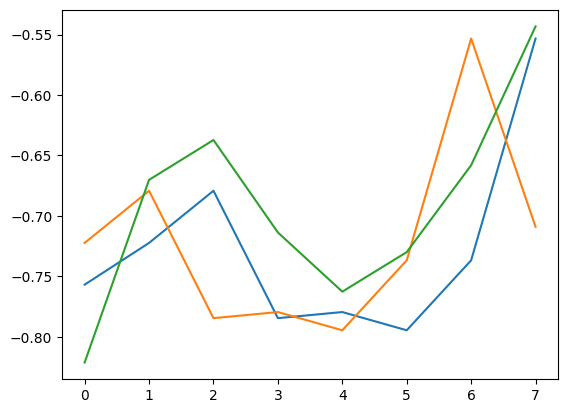

Epoch 411 Training:   0%|          | 0/11 [00:00<?, ?it/s]


ValueError: break

In [ ]:
for e in range(EPOCHS):
    if e%50 == 0:
        clear_output(wait=True)
    model.train()
    train_loss = 0
    train_se = 0
    train_count = 0
    for entities, years in tqdm(train_loader, desc=f"Epoch {e+1:>3d} Training"):
        optimizer.zero_grad()
        regional_data, global_data = load_tensor(entities, years)
        pred = model(global_data, regional_data[:, :-1])
        ground_truth = regional_data[:, 1:]
    

        loss = criterion(pred, ground_truth)
        train_loss += loss.item()

        train_se += ((pred - ground_truth)**2).sum().item()
        train_count += pred.shape[0]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        if e == 410:
            print(regional_data[0, :-1, 7])
            print(regional_data[0, 1:, 7])
            print(pred[0, :, 7])

            import matplotlib.pyplot as plt
            n = np.arange(0, len(pred[0, :, 9]))
            plt.plot(n, regional_data[0, :-1, 9].cpu(), label="input", alpha=0.5)
            plt.plot(n, regional_data[0, 1:, 9].cpu(), label="gt")
            plt.plot(n, pred[0, :, 9].cpu().detach().numpy(), label="pred")
            plt.legend()
            plt.show()
            raise ValueError("break")

    print(f"        Train Loss: {train_loss/len(train_loader)}, RMSE = {(train_se/(train_count*col_count*SEQ_LEN))**0.5}")
    train_metrics["train_loss"].append(train_loss/len(train_loader))
    train_metrics["train_rmse"].append((train_se/(train_count*col_count*SEQ_LEN))**0.5)


    model.eval()
    val_loss = 0
    val_se = 0
    val_count = 0
    with torch.no_grad():
        for entities, years in tqdm(val_loader, desc=f"               Val"):
            regional_data, global_data = load_tensor(entities, years)
            pred = model(global_data, regional_data[:, :-1])
            ground_truth = regional_data[:, -1]
            pred = pred[:, -1]
        

            loss = criterion(pred, ground_truth)
            val_loss += loss.item()

            val_se += ((pred - ground_truth)**2).sum().item()
            val_count += pred.shape[0]

    print(f"          Val Loss: {val_loss/len(val_loader)}, RMSE = {(val_se/(val_count*col_count))**0.5}")
    train_metrics["val_loss"].append(val_loss/len(val_loader))
    train_metrics["val_rmse"].append((val_se/(val_count*col_count))**0.5)

    print("                lr:", scheduler.get_last_lr()[0])
    train_metrics["lr"].append(scheduler.get_last_lr()[0])

    print()

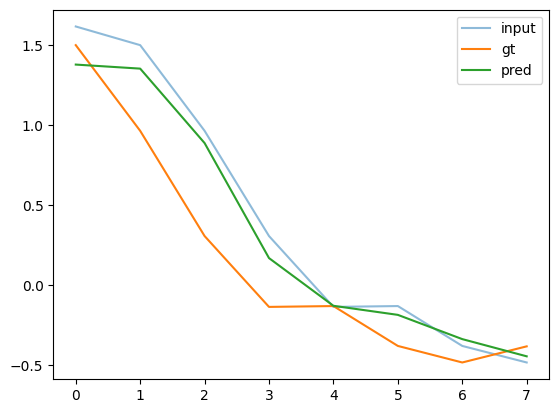

In [98]:
n = np.arange(0, len(pred[0, :, 9]))
plt.plot(n, regional_data[0, :-1, 9].cpu(), label="input", alpha=0.5)
plt.plot(n, regional_data[0, 1:, 9].cpu(), label="gt")
plt.plot(n, pred[0, :, 9].cpu().detach().numpy(), label="pred")
plt.legend()
plt.show()

In [99]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(test_loader, desc=f"Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"Test Loss: {test_loss/len(test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

Test: 100%|██████████| 2/2 [00:00<00:00,  5.91it/s]

Test Loss: 0.14476117491722107, RMSE = 0.5863716849479014


In [100]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(ood_test_loader, desc=f"OOD Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"OOD Test Loss: {test_loss/len(ood_test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

OOD Test: 100%|██████████| 3/3 [00:00<00:00,  8.40it/s]

OOD Test Loss: 0.14553360641002655, RMSE = 0.5876107909759973


# Plots

In [101]:
import matplotlib.pyplot as plt

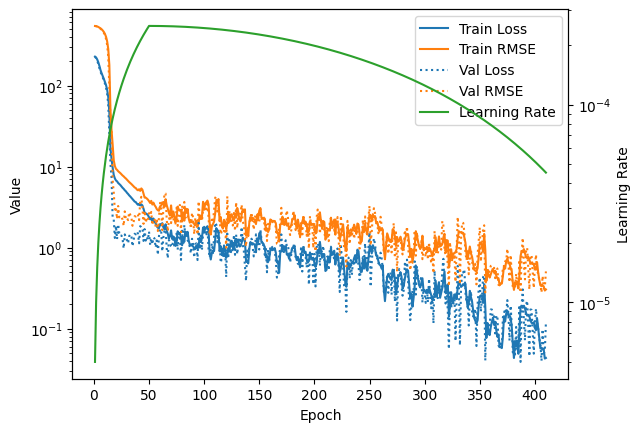

In [102]:
metrics = {k: [float(i) for i in v] for k, v in train_metrics.items()}
n = np.arange(1, len(metrics["train_loss"])+1)

fig, ax1 = plt.subplots()

ax1.plot(n, metrics["train_loss"], "C0", label="Train Loss")
ax1.plot(n, metrics["train_rmse"], "C1", label="Train RMSE")

ax1.plot(n, metrics["val_loss"], "C0:", label="Val Loss")
ax1.plot(n, metrics["val_rmse"], "C1:", label="Val RMSE")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Value")
ax1.set_yscale("log")

ax2 = ax1.twinx()

ax2.plot(n, metrics["lr"], "C2-", label="Learning Rate")
ax2.set_ylabel("Learning Rate")
ax2.set_yscale("log")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

# Comparison with Ground Truth

In [103]:
comparison_entity=["Australia"]

In [104]:
model.eval()
data = []
for years in np.append(val_year, np.append(test_year, ood_test_year)):
    print(years)
    regional_data, global_data = load_tensor(comparison_entity, np.arange(years, years + SEQ_LEN))
    pred = model(global_data, regional_data[:, :-1])

    pred = pred[:, -1, 1:].cpu().detach().numpy()
    data.append(scaler.inverse_transform(pred))

data = np.vstack(data)
test_y = np.arange(2008, 2021)
pd.DataFrame(data, columns=df_global.columns[1:])

2009
2010
2011
2012


,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,90.063568,57.315212,12.516034,154.479904,7.377766,44.380196,20.674734,71084.421875,4.336117,413491.25000,50544.984375,37.892765,7107685.0,-72.828476,149.607254
1,90.324997,54.039585,12.795178,155.052887,7.307092,47.085690,21.362625,69836.351562,4.250865,418296.71875,54441.144531,38.135807,7076814.5,-72.537422,149.362350
2,90.070534,55.221455,13.064498,155.348099,6.693990,49.638359,22.043608,69713.578125,4.153811,412720.68750,57415.527344,38.590565,7092814.5,-72.658524,149.324677
3,90.154610,54.156105,13.382731,149.282806,6.933744,59.751503,25.962381,70929.695312,4.076373,409871.09375,55228.957031,38.914707,7085455.0,-72.885445,149.241028


In [105]:
regional_data = []

for year in test_y:
    year = int(year)

    regional_data.append(torch.tensor(entity_groups[comparison_entity[0]][years_index[year]]))


regional_data = torch.stack(regional_data)
gt = regional_data.numpy()
gt = scaler.inverse_transform(gt[:, 1:])
pd.DataFrame(gt, columns=df_global.columns[1:])

/tmp/ipykernel_27442/3359583700.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  regional_data.append(torch.tensor(entity_groups[comparison_entity[0]][years_index[year]]))


,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,100.0,100.0,6.79,211.06,0.0,18.49,8.054890,72089.340,5.53,388940.0024,49654.91060,3.0,7741220.0,-25.274398,133.775136
1,100.0,100.0,7.15,216.42,0.0,18.32,7.804379,69689.840,5.43,395290.0085,42783.32257,3.0,7741220.0,-25.274398,133.775136
2,100.0,100.0,8.16,212.50,0.0,21.13,9.044215,68523.875,5.33,387540.0085,52087.97229,3.0,7741220.0,-25.274398,133.775136
3,100.0,100.0,8.32,213.56,0.0,27.33,11.345427,69714.190,5.23,386380.0049,62574.14570,3.0,7741220.0,-25.274398,133.775136
4,100.0,100.0,8.29,206.75,0.0,26.63,11.410575,67583.030,4.98,386970.0012,68027.84171,3.0,7741220.0,-25.274398,133.775136
5,100.0,100.0,9.21,195.78,0.0,34.20,14.870858,67307.040,4.93,380279.9988,68156.62792,3.0,7741220.0,-25.274398,133.775136
6,100.0,100.0,9.32,205.46,0.0,36.15,14.962130,66744.195,4.78,371630.0049,62511.69059,3.0,7741220.0,-25.274398,133.775136
7,100.0,100.0,9.31,197.72,0.0,33.12,14.347600,67234.930,4.67,377799.9878,56707.02208,3.0,7741220.0,-25.274398,133.775136
8,100.0,100.0,9.42,207.66,0.0,38.41,15.609379,66407.090,4.54,384989.9902,49881.76371,3.0,7741220.0,-25.274398,133.775136
9,100.0,100.0,9.69,209.14,0.0,40.77,16.313873,65146.316,4.49,389160.0037,53934.25018,3.0,7741220.0,-25.274398,133.775136


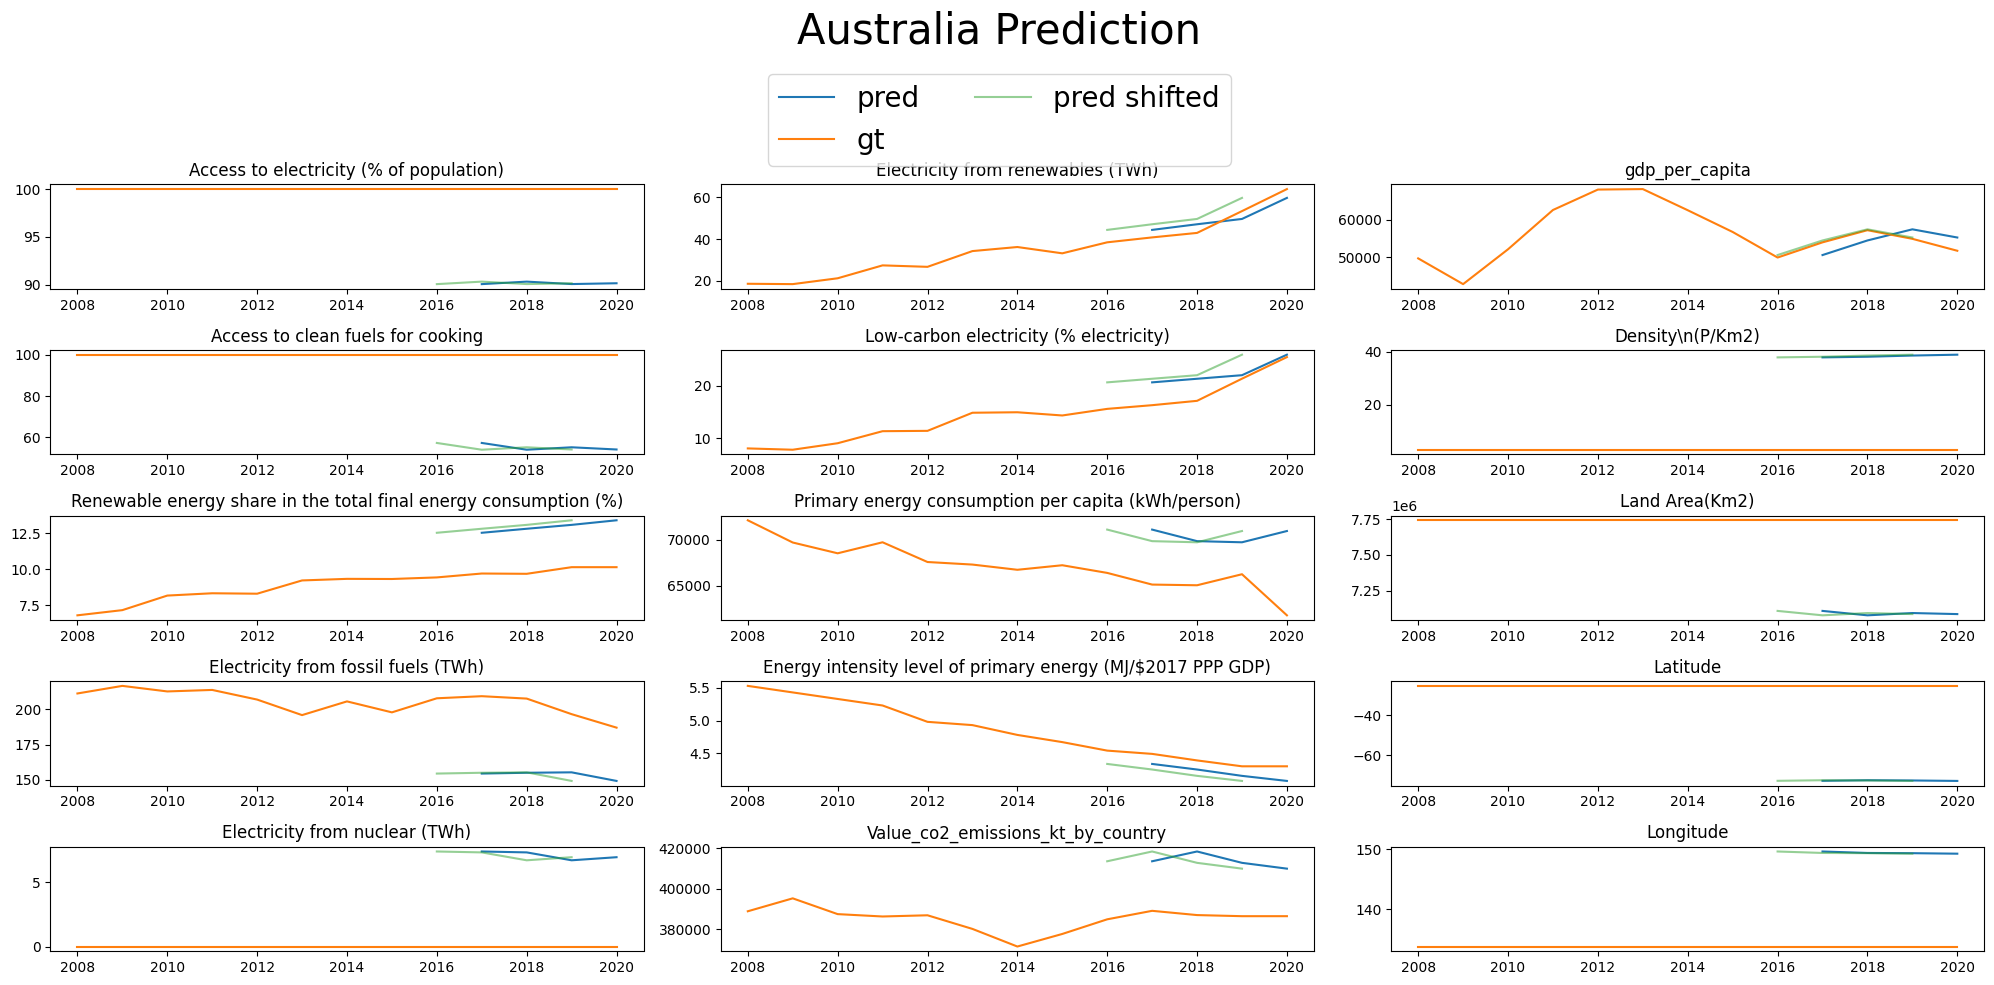

In [106]:
y = test_y[-4:]
cols = df_global.columns[1:]

fig, ax = plt.subplots(ncols=3, nrows=5, figsize=(20, 10))
for i, col in enumerate(cols):
    ax[i%5, i//5].plot(y, data[:, i], label="pred")
    ax[i%5, i//5].plot(test_y, gt[:, i], label="gt")
    ax[i%5, i//5].plot(test_y[-5:-1], data[:, i], label="pred shifted", alpha=0.5)
    ax[i%5, i//5].set_title(col, size=12)

fig.suptitle(comparison_entity[0] + " Prediction", size=30)

# Steal legend from one axis
handles, labels = ax[0, 0].get_legend_handles_labels()

# Put legend below suptitle
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),  # adjust vertically
    ncol=2,
    fontsize=20
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()